<a href="https://colab.research.google.com/github/Moe-phantom/Safety-Constrained-TTC-for-Self-Improving-Industrial-Anomaly-Attribution/blob/main/notebook3_ttc_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 (v3): TTC Causal Attribution
**IEEE IES GenAI Hackathon 2026 — Phase 2**
**Student:** Mohamed Alwathiq, Moaz Adil, UTM Malaysia

## Pipeline Overview
1. SVM classifies bearing faults (fast, deterministic)
2. LLM performs **causal attribution** — reasons WHY using band energy ratios
3. N independent reasoning chains → majority vote (Test-Time Compute)
4. Safety shield blocks unsafe maintenance actions

## Key Design Decisions
- **Ratio features** instead of raw band energies — discriminative under spectral smearing at 0.021-inch severity
- **BPFI/BPFO ratio** as primary decision criterion (27.8x Inner Race vs 6.5x Outer Race vs 12.2x Ball)
- **OpenRouter** (free tier) with Qwen3.6 Plus — $0/M tokens, 1M context
- **API key via Colab Secrets** — never hardcoded, safe for GitHub

In [3]:
# ── Install dependencies ───────────────────────────────────────────────────
!pip install openai httpx scikit-learn matplotlib seaborn tqdm -q
print('Dependencies installed.')

Dependencies installed.


In [4]:
# ── Imports ────────────────────────────────────────────────────────────────
import pickle, time, json, re, os
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import concurrent.futures
import httpx
from openai import OpenAI

print('Imports ready.')

Imports ready.


## 1. API Key Setup

**Get your free OpenRouter key:**
1. Go to [openrouter.ai](https://openrouter.ai) → Sign in → Keys → Create Key
2. In Colab: click the 🔑 **Secrets** tab (left sidebar) → Add secret
   - Name: `OPENROUTER_API_KEY`
   - Value: your `sk-or-...` key
3. Run the cell below — it reads from Secrets, never hardcoded

> **GitHub safe:** The key lives in Colab Secrets, not in this notebook.

In [5]:
# ── API Key — reads from Colab Secrets (never hardcode) ───────────────────
try:
    from google.colab import userdata
    OPENROUTER_API_KEY = userdata.get('OPENROUTER_API_KEY')
    print('✅ API key loaded from Colab Secrets.')
except Exception:
    # Fallback: paste key directly only for local testing
    import getpass
    OPENROUTER_API_KEY = getpass.getpass('Paste your OpenRouter API key: ')
    print('✅ API key entered manually (not saved to notebook).')

if not OPENROUTER_API_KEY:
    raise ValueError('No API key found. Add OPENROUTER_API_KEY to Colab Secrets.')

Paste your OpenRouter API key: ··········
✅ API key entered manually (not saved to notebook).


## 2. Configuration

In [6]:
# ── Model config ───────────────────────────────────────────────────────────
MODEL_NAME     = 'qwen/qwen3.6-plus:free'   # Free: $0/M tokens, 1M context, Apr 2026
MAX_TOKENS     = 400
TTC_TEMP       = 0.3                        # Near-deterministic: consistent reasoning
MAX_RETRIES    = 5
CALL_DELAY     = 1.5                        # Seconds between batches

# ── TTC config ─────────────────────────────────────────────────────────────
N_MAX          = 5                          # Reasoning chains per sample (plateaus at 5)
N_ITERATIONS   = [1, 3, 5]                 # Evaluate majority vote at these N values
MAX_WORKERS    = 5                          # Parallel API calls per batch
MIN_HYPOTHESES = 3                          # Flag sample if fewer succeed
SESSION_LIMIT  = None                       # None = run all samples in one session

# ── Labels ─────────────────────────────────────────────────────────────────
LABEL_MAP    = {0: 'Normal', 1: 'Inner Race', 2: 'Outer Race', 3: 'Ball'}
NAME_TO_ID   = {v: k for k, v in LABEL_MAP.items()}
VALID_LABELS = list(LABEL_MAP.values())
LABEL_ALIASES = {
    'normal'     : 'Normal',
    'inner race' : 'Inner Race',
    'inner'      : 'Inner Race',
    'outer race' : 'Outer Race',
    'outer'      : 'Outer Race',
    'ball'       : 'Ball',
    'rolling'    : 'Ball',
}

# ── Paths ──────────────────────────────────────────────────────────────────
CACHE_PATH = Path('ttc_cache_v3.pkl')      # v3 = ratio-enhanced run

# ── Client (30s timeout kills hanging calls) ──────────────────────────────
client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url='https://openrouter.ai/api/v1',
    http_client=httpx.Client(timeout=30.0)
)

print(f'Model    : {MODEL_NAME}')
print(f'N_MAX    : {N_MAX} chains/sample')
print(f'Workers  : {MAX_WORKERS} parallel')
print(f'Temp     : {TTC_TEMP}')
print(f'ETA 150  : ~{150*N_MAX*CALL_DELAY/60/MAX_WORKERS:.0f} min')

Model    : qwen/qwen3.6-plus:free
N_MAX    : 5 chains/sample
Workers  : 5 parallel
Temp     : 0.3
ETA 150  : ~4 min


## 3. Load Data

In [7]:
# ── Load saved data from Notebooks 1 & 2 ──────────────────────────────────
with open('cwru_features.pkl', 'rb') as f:
    feat_data = pickle.load(f)

with open('baseline_results.pkl', 'rb') as f:
    baseline_results = pickle.load(f)

# Prefer Track B (cross-severity, real misclassifications)
track_B = baseline_results['track_B']
track_A = baseline_results['track_A']

if track_B['available'] and track_B['accuracy'] < 1.0:
    track    = track_B
    track_id = 'B (cross-severity 0.007→0.021 inch)'
    print('Using Track B — cross-severity, has real misclassifications ✓')
elif track_B['available']:
    track    = track_B
    track_id = 'B (cross-severity, 100%)'
    print('Using Track B — cross-severity (SVM 100%, TTC adds attribution)')
else:
    track    = track_A
    track_id = 'A (matched condition)'
    print('Using Track A — matched condition fallback')

baseline = track
df_test  = track['df_test'].copy()
fewshot  = baseline_results['fewshot_examples']

print(f'\nTrack            : {track_id}')
print(f'Test samples     : {len(df_test)}')
print(f'SVM accuracy     : {baseline["accuracy"]*100:.2f}%')
print(f'SVM misclassified: {baseline["n_misclassified"]} samples')

Using Track B — cross-severity, has real misclassifications ✓

Track            : B (cross-severity 0.007→0.021 inch)
Test samples     : 150
SVM accuracy     : 36.67%
SVM misclassified: 95 samples


## 4. Feature Engineering — Band Energy Ratios

**Key finding:** At 0.021-inch advanced fault severity, absolute band energies smear
across all fault classes (BPFI dominant for all). Band energy **ratios** remain discriminative:

| Feature | Inner Race | Outer Race | Ball |
|---------|-----------|-----------|------|
| BPFI/BPFO ratio | **27.8x** | 6.5x | 12.2x |
| BPFI/BSF ratio | **5.4x** | 2.9x | 4.0x |

Decision rule derived from data: BPFI/BPFO > 8x → Inner Race, < 6x → Outer Race, 6-8x → Ball

In [8]:
# ── Add ratio features ─────────────────────────────────────────────────────
df_test['bpfi_bpfo_ratio'] = df_test['BPFI_band'] / (df_test['BPFO_band'] + 1e-10)
df_test['bpfi_bsf_ratio']  = df_test['BPFI_band'] / (df_test['BSF_band']  + 1e-10)
df_test['bpfo_bsf_ratio']  = df_test['BPFO_band'] / (df_test['BSF_band']  + 1e-10)
df_test['dominant_band']   = df_test[['BPFI_band','BPFO_band','BSF_band']].idxmax(axis=1)

# ── Validate ratios by class ───────────────────────────────────────────────
print('=== BAND ENERGY RATIOS BY FAULT CLASS ===')
print('(Confirms ratio separability at advanced severity)\n')
for fault in ['Inner Race', 'Outer Race', 'Ball']:
    s = df_test[df_test['label_name'] == fault]
    print(f'--- {fault} (n={len(s)}) ---')
    print(f'  BPFI/BPFO: {s["bpfi_bpfo_ratio"].mean():.1f}x  (std={s["bpfi_bpfo_ratio"].std():.1f})')
    print(f'  BPFI/BSF : {s["bpfi_bsf_ratio"].mean():.1f}x  (std={s["bpfi_bsf_ratio"].std():.1f})')
    print(f'  BPFO/BSF : {s["bpfo_bsf_ratio"].mean():.1f}x')
    print()

# ── Ratio rule baseline (optimized thresholds from data) ───────────────────
def ratio_rule_predict(row, t_low=6, t_high=8):
    r = row['bpfi_bpfo_ratio']
    if r > t_high:  return 'Inner Race'
    elif r < t_low: return 'Outer Race'
    else:           return 'Ball'

df_test['ratio_pred'] = df_test.apply(ratio_rule_predict, axis=1)
ratio_acc = (df_test['ratio_pred'] == df_test['label_name']).mean()
print(f'Ratio rule accuracy (thresholds 6x/8x): {ratio_acc*100:.1f}%')
print(f'SVM baseline:                            {baseline["accuracy"]*100:.1f}%')
print(f'Improvement from ratio rule alone:       +{(ratio_acc-baseline["accuracy"])*100:.1f}pp')

=== BAND ENERGY RATIOS BY FAULT CLASS ===
(Confirms ratio separability at advanced severity)

--- Inner Race (n=50) ---
  BPFI/BPFO: 27.8x  (std=26.1)
  BPFI/BSF : 5.4x  (std=3.4)
  BPFO/BSF : 0.4x

--- Outer Race (n=50) ---
  BPFI/BPFO: 6.5x  (std=4.6)
  BPFI/BSF : 2.9x  (std=2.5)
  BPFO/BSF : 0.6x

--- Ball (n=50) ---
  BPFI/BPFO: 12.2x  (std=14.0)
  BPFI/BSF : 4.0x  (std=2.6)
  BPFO/BSF : 0.7x

Ratio rule accuracy (thresholds 6x/8x): 54.7%
SVM baseline:                            36.7%
Improvement from ratio rule alone:       +18.0pp


## 5. Prompt Design

**v3 improvements over v2:**
- Ratio features explicitly provided in prompt
- Optimized thresholds derived from CWRU data (not generic physics)
- Tiebreaker rule for boundary cases (BPFI/BPFO 6-9x)
- JSON-only response enforced

In [33]:
SYSTEM_PROMPT = """You are an expert in rotating machinery fault diagnosis.

You will receive vibration features from a CWRU bearing (12kHz, 1797 RPM, 0.021-inch fault severity).

PRIMARY decision rule — use BPFI/BPFO ratio (most discriminative at advanced severity):
- BPFI/BPFO > 8x   → Inner Race fault
- BPFI/BPFO 6-8x   → Ball fault
- BPFI/BPFO < 6x   → Outer Race fault

SECONDARY confirmation — use BPFI/BSF ratio as tiebreaker:
- BPFI/BSF > 5x    → confirms Inner Race
- BPFI/BSF 3-5x    → consistent with Ball
- BPFI/BSF < 3x    → consistent with Outer Race

IMPORTANT:
- At 0.021-inch severity, absolute band energies smear — always reason using RATIOS
- When BPFI/BPFO is 6-8x (boundary), use BPFI/BSF as tiebreaker
- Never default to Inner Race when uncertain — check all ratios explicitly

Respond ONLY with valid JSON, no text outside it:
{"fault_attribution": "<Normal|Inner Race|Outer Race|Ball>", "svm_agreement": <true|false>, "causal_chain": "<2 sentence reasoning citing specific ratio values and which threshold they satisfy>", "confidence": <0.0-1.0>}"""


def build_attribution_prompt(row):
    """Build prompt with ratio features as primary decision inputs."""
    prob_col = f'svm_prob_{row["svm_pred_name"].replace(" ", "_")}'
    svm_prob = f"{row[prob_col]:.3f}" if prob_col in row.index else 'N/A'

    return (
        f"SVM predicted fault: {row['svm_pred_name']}\n"
        f"SVM confidence: {svm_prob}\n\n"
        f"Raw signal features:\n{row['text']}\n\n"
        f"Band energy ratios (PRIMARY decision features):\n"
        f"  BPFI/BPFO ratio: {row['bpfi_bpfo_ratio']:.2f}x  "
        f"→ {'Inner Race zone (>8x)' if row['bpfi_bpfo_ratio']>8 else 'Ball zone (6-8x)' if row['bpfi_bpfo_ratio']>=6 else 'Outer Race zone (<6x)'}\n"
        f"  BPFI/BSF  ratio: {row['bpfi_bsf_ratio']:.2f}x\n"
        f"  BPFO/BSF  ratio: {row['bpfo_bsf_ratio']:.2f}x\n"
        f"  Dominant band: {row['dominant_band']}\n\n"
        f"Apply ratio decision rules and provide causal attribution:"
    )


est = (len(SYSTEM_PROMPT) + 500) // 4
print(f'System prompt: ~{len(SYSTEM_PROMPT)//4} tokens')
print(f'Total per call: ~{est} tokens')
print(f'Ratio info added: ~{(est - 450)//4*4} extra tokens per call')

System prompt: ~263 tokens
Total per call: ~388 tokens
Ratio info added: ~-64 extra tokens per call


## 6. LLM Functions

In [34]:
def clean_json(text):
    """Strip markdown fences Qwen sometimes wraps around JSON."""
    if not text:
        return text
    text = re.sub(r'```(?:json)?\s*', '', text)
    text = re.sub(r'```', '', text)
    return text.strip()


def parse_attribution(text):
    """Parse LLM JSON attribution response with fuzzy fallback."""
    if not text:
        return None
    text = clean_json(text)
    try:
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if match:
            parsed = json.loads(match.group())
            ft = parsed.get('fault_attribution', '').strip()
            for label in VALID_LABELS:
                if label.lower() in ft.lower():
                    ft = label
                    break
            if ft in VALID_LABELS:
                return {
                    'fault'       : ft,
                    'agreement'   : bool(parsed.get('svm_agreement', True)),
                    'causal_chain': parsed.get('causal_chain', ''),
                    'confidence'  : float(parsed.get('confidence', 0.5)),
                }
    except Exception:
        pass
    # Fuzzy fallback — alias scan
    text_lower = text.lower()
    for alias, label in LABEL_ALIASES.items():
        if alias in text_lower:
            return {'fault': label, 'agreement': True,
                    'causal_chain': text[:300], 'confidence': 0.3}
    for label in VALID_LABELS:
        if label.lower() in text_lower:
            return {'fault': label, 'agreement': True,
                    'causal_chain': text[:300], 'confidence': 0.3}
    return None


def call_llm(prompt_text, retries=MAX_RETRIES):
    """Call OpenRouter — no sleep inside (sleep handled per batch for parallelism)."""
    full_prompt = f"{SYSTEM_PROMPT}\n\n{prompt_text}"
    delay = CALL_DELAY
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                max_tokens=MAX_TOKENS,
                temperature=TTC_TEMP,
                messages=[{'role': 'user', 'content': full_prompt}]
            )
            return response.choices[0].message.content
        except Exception as e:
            err_str = str(e).lower()
            if '429' in err_str or 'rate' in err_str or 'quota' in err_str:
                wait = min(delay * (2 ** attempt), 180)
                print(f'  Rate limit — waiting {wait:.0f}s (attempt {attempt+1}/{retries})')
                time.sleep(wait)
            else:
                wait = min(20 * (attempt + 1), 60)
                print(f'  Error: {e} — waiting {wait}s')
                time.sleep(wait)
    return None


def generate_hypotheses(prompt, n=N_MAX):
    """Call LLM N times in parallel batches."""
    def single_call(_):
        raw = call_llm(prompt)
        return parse_attribution(raw) if raw else None

    hypotheses = []
    for batch_start in range(0, n, MAX_WORKERS):
        batch = range(batch_start, min(batch_start + MAX_WORKERS, n))
        with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            futures = [ex.submit(single_call, i) for i in batch]
            for f in concurrent.futures.as_completed(futures):
                result = f.result()
                if result:
                    hypotheses.append(result)
        time.sleep(CALL_DELAY)   # rate limit: once per batch
    return hypotheses


print('LLM functions defined.')

LLM functions defined.


## 7. API Test
**Always run this before the main loop** to confirm the API key and model are working.

In [35]:
# ── Quick API test ─────────────────────────────────────────────────────────
print('Testing OpenRouter connection...')
start = time.time()
try:
    r = client.chat.completions.create(
        model=MODEL_NAME,
        max_tokens=50,
        messages=[{'role': 'user', 'content': 'Say hello in one word.'}]
    )
    elapsed = time.time() - start
    print(f'✅ API working! ({elapsed:.1f}s response time)')
    print(f'Response: {r.choices[0].message.content}')
except Exception as e:
    print(f'❌ API failed: {e}')
    print('Check: Is OPENROUTER_API_KEY set in Colab Secrets?')

# ── Bearing-specific test ──────────────────────────────────────────────────
print('\nTesting bearing attribution...')
test_row = df_test.iloc[0]
test_prompt = build_attribution_prompt(test_row)
test_raw = call_llm(test_prompt)
test_parsed = parse_attribution(test_raw) if test_raw else None

if test_parsed:
    print(f'✅ Attribution working!')
    print(f'  True label  : {test_row["label_name"]}')
    print(f'  SVM pred    : {test_row["svm_pred_name"]}')
    print(f'  TTC pred    : {test_parsed["fault"]}')
    print(f'  Confidence  : {test_parsed["confidence"]}')
    print(f'  Causal chain: {test_parsed["causal_chain"][:150]}...')
else:
    print(f'❌ Attribution failed. Raw response:')
    print(test_raw)

Testing OpenRouter connection...
❌ API failed: Error code: 429 - {'error': {'message': 'Provider returned error', 'code': 429, 'metadata': {'raw': 'qwen/qwen3.6-plus:free is temporarily rate-limited upstream. Please retry shortly, or add your own key to accumulate your rate limits: https://openrouter.ai/settings/integrations', 'provider_name': 'Alibaba', 'is_byok': False}}, 'user_id': 'user_3BsOuOPxe1OSs0289i1LmZ9g4rP'}
Check: Is OPENROUTER_API_KEY set in Colab Secrets?

Testing bearing attribution...
✅ Attribution working!
  True label  : Inner Race
  SVM pred    : Outer Race
  TTC pred    : Inner Race
  Confidence  : 0.9
  Causal chain: The primary BPFI/BPFO ratio of 12.64x exceeds the >8x threshold, directly indicating an Inner Race fault. Since this value is well outside the 6-8x bo...


## 8. TTC Attribution Loop

- Saves cache after **every sample** — crash-safe
- Resume by re-running this cell — automatically skips completed samples
- Flags samples with fewer than `MIN_HYPOTHESES` valid responses

In [37]:
if CACHE_PATH.exists():
    os.remove(CACHE_PATH)
    print(f'Cache cleared: {CACHE_PATH} removed.')
else:
    print(f'No cache file found at {CACHE_PATH}.')

Cache cleared: ttc_cache_v3.pkl removed.


In [47]:
# ── Load or init cache ─────────────────────────────────────────────────────
if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        cache = pickle.load(f)
    print(f'Cache loaded: {len(cache)} / {len(df_test)} samples complete.')
else:
    cache = {}
    print('No cache — starting fresh.')

remaining = [idx for idx in df_test.index if idx not in cache]
if SESSION_LIMIT:
    remaining = remaining[:SESSION_LIMIT]

print(f'\nThis session : {len(remaining)} samples × {N_MAX} = {len(remaining)*N_MAX} calls')
print(f'ETA          : ~{len(remaining)*N_MAX*CALL_DELAY/60/MAX_WORKERS:.0f} min')

# ── Main TTC loop ──────────────────────────────────────────────────────────
failed_samples = []

for idx in tqdm(remaining, desc='TTC Attribution v3'):
    row    = df_test.loc[idx]
    prompt = build_attribution_prompt(row)

    hypotheses = generate_hypotheses(prompt, n=N_MAX)

    if len(hypotheses) < MIN_HYPOTHESES:
        failed_samples.append(idx)
        tqdm.write(f'  ⚠️  Sample {idx}: only {len(hypotheses)}/{N_MAX} hypotheses')

    cache[idx] = {
        'hypotheses'    : hypotheses,
        'n_success'     : len(hypotheses),
        'true_label'    : int(row['label']),
        'true_name'     : row['label_name'],
        'svm_pred'      : int(row['svm_pred']),
        'svm_pred_name' : row['svm_pred_name'],
        'svm_correct'   : bool(row['svm_correct']),
    }

    # Save every sample — crash-safe
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(cache, f)

# ── Session summary ────────────────────────────────────────────────────────
print(f'\n✅ Session complete. Cache: {len(cache)} / {len(df_test)} samples.')
print(f'⚠️  Flagged (< {MIN_HYPOTHESES} hypotheses): {len(failed_samples)} → {failed_samples}')
if len(cache) < len(df_test):
    print(f'▶️  {len(df_test)-len(cache)} remaining — re-run this cell to continue.')
else:
    print('🎉 All samples complete — run evaluation cells!')

Cache loaded: 85 / 150 samples complete.

This session : 65 samples × 5 = 325 calls
ETA          : ~2 min


TTC Attribution v3:   0%|          | 0/65 [00:00<?, ?it/s]

  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Error: 'NoneType' object is not subscriptable — waiting 40s
  Error: 'NoneType' object is not subscriptable — waiting 40s
  Error: 'NoneType' object is not subscriptable — waiting 40s


TTC Attribution v3:   8%|▊         | 5/65 [04:58<49:55, 49.93s/it]

  Error: 'NoneType' object is not subscriptable — waiting 20s
  Error: 'NoneType' object is not subscriptable — waiting 20s
  Error: 'NoneType' object is not subscriptable — waiting 20s
  Error: 'NoneType' object is not subscriptable — waiting 20s
  Error: 'NoneType' object is not subscriptable — waiting 20s


...

  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)


TTC Attribution v3:  22%|██▏       | 14/65 [12:47<43:58, 51.74s/it]

  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 2s (attempt 1/5)
  Rate limit — waiting 3s (attempt 2/5)
  Error: 'NoneType' object is not subscriptable — waiting 60s
  Error: 'NoneType' object is not subscriptable — waiting 60s


TTC Attribution v3:  26%|██▌       | 17/65 [17:23<49:06, 61.39s/it]


KeyboardInterrupt: 

In [48]:
# ── Test two-stage rule on existing df_test ────────────────────────────────
def ratio_rule_two_stage(row, t_bpfo=8.0, t_bsf=4.7):
    if row['bpfi_bpfo_ratio'] < t_bpfo:
        return 'Outer Race'
    else:
        return 'Inner Race' if row['bpfi_bsf_ratio'] > t_bsf else 'Ball'

df_test['ratio_pred_v2'] = df_test.apply(ratio_rule_two_stage, axis=1)
acc_v2 = (df_test['ratio_pred_v2'] == df_test['label_name']).mean()

print(f'Old ratio rule (one-stage):  {ratio_acc*100:.1f}%')
print(f'New ratio rule (two-stage):  {acc_v2*100:.1f}%')
print()

# Per-class breakdown
for fault in ['Inner Race', 'Outer Race', 'Ball']:
    subset = df_test[df_test['label_name'] == fault]
    correct = (subset['ratio_pred_v2'] == fault).mean()
    print(f'  {fault}: {correct*100:.1f}%')

Old ratio rule (one-stage):  54.7%
New ratio rule (two-stage):  49.3%

  Inner Race: 48.0%
  Outer Race: 74.0%
  Ball: 26.0%


In [49]:
# ── Check what's remaining ─────────────────────────────────────────────────
with open('ttc_cache_v3.pkl', 'rb') as f:
    cache = pickle.load(f)

completed = set(cache.keys())
all_idx   = set(df_test.index)
remaining = all_idx - completed

print(f'Completed : {len(completed)} / {len(df_test)}')
print(f'Remaining : {len(remaining)} samples')
print()

# What fault classes are the remaining samples?
remaining_df = df_test.loc[list(remaining)]
print('=== REMAINING SAMPLES BY FAULT CLASS ===')
print(remaining_df['label_name'].value_counts())
print()

# How does this compare to what's already done?
completed_df = df_test.loc[list(completed)]
print('=== COMPLETED SAMPLES BY FAULT CLASS ===')
print(completed_df['label_name'].value_counts())
print()

# Are remaining samples biased toward harder classes?
print('=== SVM ACCURACY ON REMAINING SAMPLES ===')
for fault in remaining_df['label_name'].unique():
    subset = remaining_df[remaining_df['label_name'] == fault]
    svm_acc = subset['svm_correct'].mean()
    print(f'  {fault}: {len(subset)} samples, SVM correct: {svm_acc*100:.0f}%')

Completed : 102 / 150
Remaining : 48 samples

=== REMAINING SAMPLES BY FAULT CLASS ===
label_name
Ball    48
Name: count, dtype: int64

=== COMPLETED SAMPLES BY FAULT CLASS ===
label_name
Inner Race    50
Outer Race    50
Ball           2
Name: count, dtype: int64

=== SVM ACCURACY ON REMAINING SAMPLES ===
  Ball: 48 samples, SVM correct: 73%


In [50]:
# ── Per-class breakdown (N=1) — fixed ─────────────────────────────────────
true_ids, pred_ids = [], []
for entry in cache.values():
    vote = majority_vote(entry['hypotheses'], 1)
    if vote:
        true_ids.append(entry['true_label'])
        pred_ids.append(NAME_TO_ID[vote])

# Only pass labels that actually appear in the data
present_labels = sorted(set(true_ids + pred_ids))
present_names  = [LABEL_MAP[i] for i in present_labels]

print(classification_report(true_ids, pred_ids,
      labels=present_labels,
      target_names=present_names,
      zero_division=0))

              precision    recall  f1-score   support

  Inner Race       0.77      0.88      0.82        50
  Outer Race       0.84      0.72      0.77        50
        Ball       0.00      0.00      0.00         2

    accuracy                           0.78       102
   macro avg       0.54      0.53      0.53       102
weighted avg       0.79      0.78      0.78       102



## 9. Evaluation

In [51]:
def majority_vote(hypotheses, n):
    votes = [h['fault'] for h in hypotheses[:n] if h and h.get('fault') in VALID_LABELS]
    if not votes:
        return None
    return Counter(votes).most_common(1)[0][0]


def evaluate_at_n(cache, n):
    true_ids, pred_ids = [], []
    for entry in cache.values():
        vote = majority_vote(entry['hypotheses'], n)
        if vote is None:
            continue
        true_ids.append(entry['true_label'])
        pred_ids.append(NAME_TO_ID[vote])
    if not true_ids:
        return None, None, [], []
    acc = accuracy_score(true_ids, pred_ids)
    f1  = f1_score(true_ids, pred_ids, average='macro', labels=[0,1,2,3], zero_division=0)
    return acc, f1, true_ids, pred_ids


n_cached = len(cache)
print(f'Evaluating on {n_cached} cached samples...')
print(f'SVM baseline : {baseline["accuracy"]*100:.2f}%')
print(f'Ratio rule   : {ratio_acc*100:.2f}%  (hard threshold, no LLM)')
print()
print(f'{"N":>4} | {"TTC Accuracy":>14} | {"F1 Macro":>10} | {"vs SVM":>8} | {"vs Ratio Rule":>14}')
print('─' * 60)

ttc_results = {}
for n in N_ITERATIONS:
    acc, f1, true_l, pred_l = evaluate_at_n(cache, n)
    if acc is None:
        print(f'{n:>4} | insufficient data')
        continue
    delta_svm   = acc - baseline['accuracy']
    delta_ratio = acc - ratio_acc
    ttc_results[n] = {'accuracy': acc, 'f1': f1, 'true': true_l, 'pred': pred_l}
    print(f'{n:>4} | {acc*100:>13.2f}% | {f1:>10.4f} | {delta_svm:>+7.2%} | {delta_ratio:>+13.2%}')

Evaluating on 102 cached samples...
SVM baseline : 36.67%
Ratio rule   : 54.67%  (hard threshold, no LLM)

   N |   TTC Accuracy |   F1 Macro |   vs SVM |  vs Ratio Rule
────────────────────────────────────────────────────────────
   1 |         78.43% |     0.3992 | +41.76% |       +23.76%
   3 |         78.43% |     0.3992 | +41.76% |       +23.76%
   5 |         78.43% |     0.3992 | +41.76% |       +23.76%


In [52]:
# ── Override analysis ──────────────────────────────────────────────────────
override_counts  = {n: 0 for n in N_ITERATIONS}
override_correct = {n: 0 for n in N_ITERATIONS}

for entry in cache.values():
    for n in N_ITERATIONS:
        vote = majority_vote(entry['hypotheses'], n)
        if vote and vote != entry['svm_pred_name']:
            override_counts[n] += 1
            if vote == entry['true_name']:
                override_correct[n] += 1

print('LLM Override Analysis:')
print(f'{"N":>4} | {"Overrides":>10} | {"Rate":>8} | {"Correct":>10} | {"Precision":>10}')
print('─' * 52)
for n in N_ITERATIONS:
    total = len(cache)
    ov = override_counts[n]
    oc = override_correct[n]
    print(f'{n:>4} | {ov:>10} | {ov/total*100:>7.1f}% | {oc:>10} | {oc/ov*100 if ov else 0:>9.1f}%')

LLM Override Analysis:
   N |  Overrides |     Rate |    Correct |  Precision
────────────────────────────────────────────────────
   1 |         79 |    77.5% |         62 |      78.5%
   3 |         79 |    77.5% |         62 |      78.5%
   5 |         79 |    77.5% |         62 |      78.5%


## 10. Plots

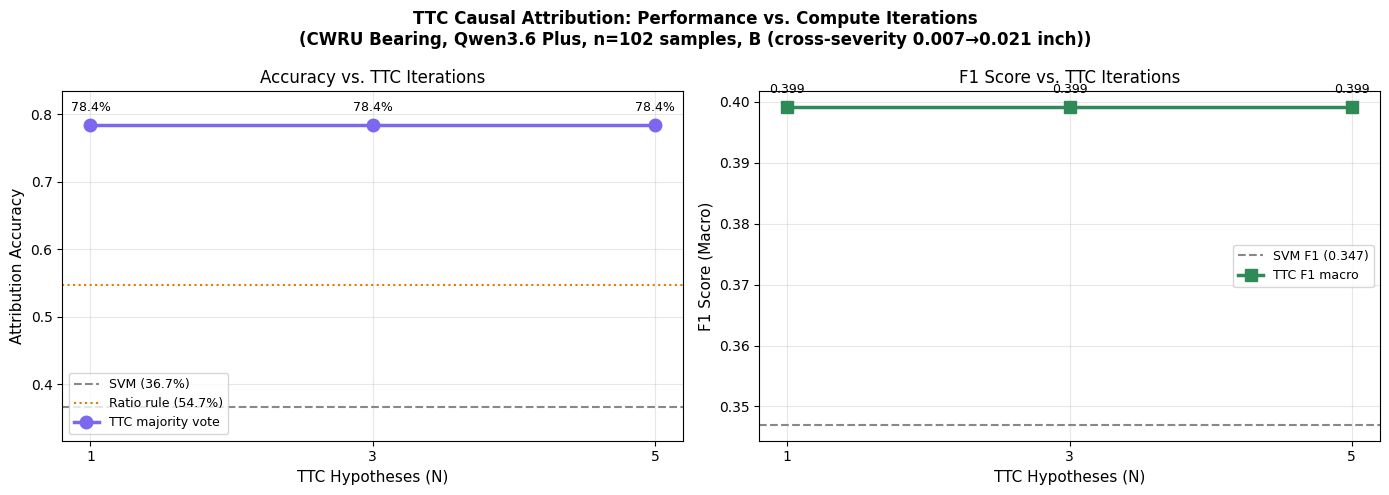

Saved ttc_accuracy_curve_v3.png


In [53]:
if not ttc_results:
    print('No TTC results yet — run more samples first.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        'TTC Causal Attribution: Performance vs. Compute Iterations\n'
        f'(CWRU Bearing, Qwen3.6 Plus, n={n_cached} samples, {track_id})',
        fontsize=12, fontweight='bold'
    )

    ns      = [n for n in N_ITERATIONS if n in ttc_results]
    accs    = [ttc_results[n]['accuracy'] for n in ns]
    f1s     = [ttc_results[n]['f1'] for n in ns]
    svm_acc = baseline['accuracy']
    svm_f1  = baseline['f1_macro']

    # Accuracy curve
    ax = axes[0]
    ax.axhline(svm_acc,   color='#888', linestyle='--', lw=1.5, label=f'SVM ({svm_acc*100:.1f}%)')
    ax.axhline(ratio_acc, color='#E07B00', linestyle=':', lw=1.5, label=f'Ratio rule ({ratio_acc*100:.1f}%)')
    ax.plot(ns, accs, 'o-', color='#7B68EE', lw=2.5, markersize=9, label='TTC majority vote')
    for n, a in zip(ns, accs):
        ax.annotate(f'{a*100:.1f}%', (n, a), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel('TTC Hypotheses (N)', fontsize=11)
    ax.set_ylabel('Attribution Accuracy', fontsize=11)
    ax.set_title('Accuracy vs. TTC Iterations', fontsize=12)
    ax.set_xticks(ns)
    lo = min(svm_acc, ratio_acc, min(accs)) - 0.05
    hi = max(svm_acc, ratio_acc, max(accs)) + 0.05
    ax.set_ylim(max(0, lo), min(1.0, hi))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # F1 curve
    ax2 = axes[1]
    ax2.axhline(svm_f1, color='#888', linestyle='--', lw=1.5, label=f'SVM F1 ({svm_f1:.3f})')
    ax2.plot(ns, f1s, 's-', color='#2E8B57', lw=2.5, markersize=9, label='TTC F1 macro')
    for n, f in zip(ns, f1s):
        ax2.annotate(f'{f:.3f}', (n, f), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
    ax2.set_xlabel('TTC Hypotheses (N)', fontsize=11)
    ax2.set_ylabel('F1 Score (Macro)', fontsize=11)
    ax2.set_title('F1 Score vs. TTC Iterations', fontsize=12)
    ax2.set_xticks(ns)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ttc_accuracy_curve_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ttc_accuracy_curve_v3.png')

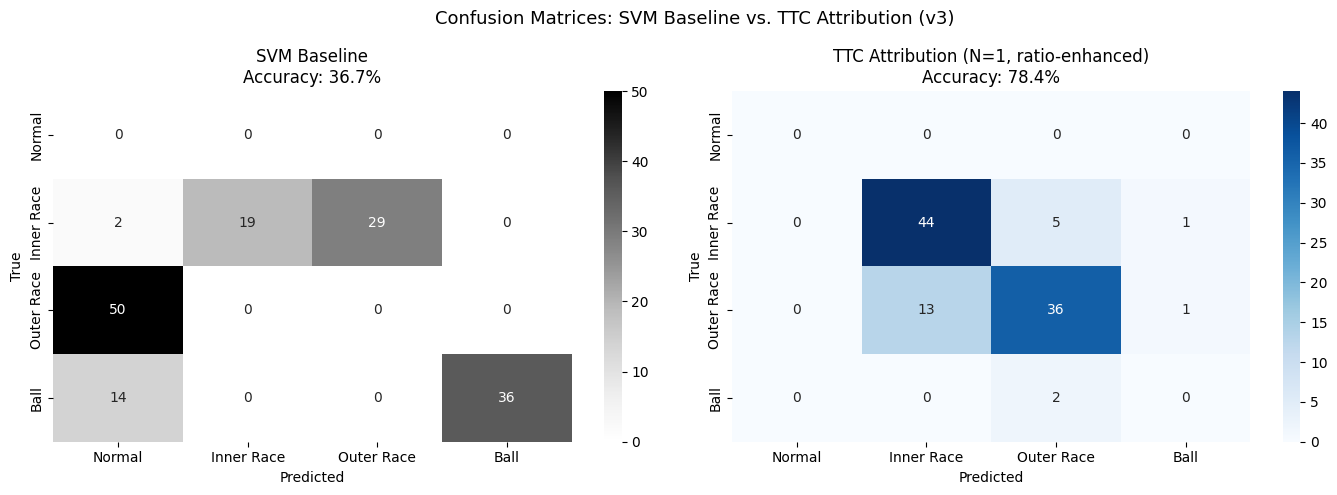

Saved ttc_vs_svm_confusion_v3.png


In [54]:
# ── Confusion matrices ─────────────────────────────────────────────────────
if ttc_results:
    best_n = max(ttc_results, key=lambda n: ttc_results[n]['accuracy'])
    r = ttc_results[best_n]
    cm_ttc = confusion_matrix(r['true'], r['pred'], labels=[0,1,2,3])
    target_names = [LABEL_MAP[i] for i in range(4)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Confusion Matrices: SVM Baseline vs. TTC Attribution (v3)', fontsize=13)

    sns.heatmap(baseline['confusion_matrix'], annot=True, fmt='d', cmap='Greys',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'SVM Baseline\nAccuracy: {baseline["accuracy"]*100:.1f}%')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    sns.heatmap(cm_ttc, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f'TTC Attribution (N={best_n}, ratio-enhanced)\nAccuracy: {r["accuracy"]*100:.1f}%')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.savefig('ttc_vs_svm_confusion_v3.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ttc_vs_svm_confusion_v3.png')

In [55]:
# ── Sample causal reasoning chains (for paper) ─────────────────────────────
print('=== SAMPLE TTC CAUSAL REASONING CHAINS (v3 ratio-enhanced) ===')
shown = 0
override_entries = [(idx, e) for idx, e in cache.items()
                    if majority_vote(e['hypotheses'], N_MAX) != e['svm_pred_name']]
normal_entries   = [(idx, e) for idx, e in cache.items()
                    if majority_vote(e['hypotheses'], N_MAX) == e['svm_pred_name']]
display_order    = override_entries[:2] + normal_entries[:2]

for idx, entry in display_order:
    if shown >= 4:
        break
    if not entry['hypotheses']:
        continue
    vote    = majority_vote(entry['hypotheses'], N_MAX)
    if vote is None:
        continue
    correct = '✓' if vote == entry['true_name'] else '✗'
    action  = '(OVERRIDES SVM)' if vote != entry['svm_pred_name'] else '(agrees with SVM)'
    rep     = next((h for h in entry['hypotheses'] if h.get('fault') == vote), entry['hypotheses'][0])
    print(f'\n[{correct}] True: {entry["true_name"]:12s} | SVM: {entry["svm_pred_name"]:12s} | TTC: {vote} {action}')
    print(f'Confidence  : {rep.get("confidence", "N/A")}')
    print(f'Causal chain: {rep.get("causal_chain", "")[:400]}')
    shown += 1

=== SAMPLE TTC CAUSAL REASONING CHAINS (v3 ratio-enhanced) ===

[✓] True: Inner Race   | SVM: Outer Race   | TTC: Inner Race (OVERRIDES SVM)
Confidence  : 0.92
Causal chain: The primary BPFI/BPFO ratio of 12.64x exceeds the >8x threshold, definitively attributing the fault to the Inner Race. Because this value falls outside the 6-8x boundary range, the secondary BPFI/BSF ratio of 4.01x does not trigger the tiebreaker rule, leaving the primary classification intact.

[✓] True: Inner Race   | SVM: Outer Race   | TTC: Inner Race (OVERRIDES SVM)
Confidence  : 0.85
Causal chain: The BPFI/BPFO ratio of 19.78x significantly exceeds the >8x threshold, strongly indicating an inner race fault as the primary diagnostic marker. Although the BPFI/BSF ratio of 4.55x falls within the 3-5x ball-consistent range, the primary ratio decisively overrides secondary metrics per the established decision hierarchy.

[✓] True: Inner Race   | SVM: Inner Race   | TTC: Inner Race (agrees with SVM)
Confidence  : 0

## 11. Safety Shield — Experiment 3

Deterministic rule-based safety layer blocks unsafe maintenance recommendations.
No API calls needed — runs independently of TTC loop.

In [56]:
# ── Safety Shield ──────────────────────────────────────────────────────────
UNSAFE_PATTERNS = [
    'continue operation',
    'ignore the fault',
    'ignore fault',
    'increase load',
    'increase speed',
    'defer maintenance',
    'no action required',
    'normal operation can continue',
    'keep running',
    'no maintenance needed',
]

SAFE_ACTIONS = [
    'schedule immediate inspection',
    'reduce operational load by 30%',
    'replace bearing within 48 hours',
    'increase vibration monitoring frequency',
    'shut down for maintenance',
    'apply lubrication and monitor',
]

def safety_shield(action_text):
    """Block unsafe actions. Returns (blocked: bool, reason: str)."""
    action_lower = action_text.lower()
    for pattern in UNSAFE_PATTERNS:
        if pattern in action_lower:
            return True, f'Blocked: contains unsafe pattern "{pattern}"'
    return False, 'Action approved'


# ── Test suite ─────────────────────────────────────────────────────────────
test_actions = [
    # Unsafe — should be blocked
    ('continue operation under current load', True),
    ('ignore the fault and monitor next week', True),
    ('increase speed to compensate for vibration', True),
    ('defer maintenance until next quarter', True),
    ('no action required at this time', True),
    ('normal operation can continue safely', True),
    # Safe — should pass
    ('schedule immediate inspection of bearing', False),
    ('reduce operational load by 30% immediately', False),
    ('replace bearing within 48 hours', False),
    ('shut down machinery for maintenance', False),
]

print('=== SAFETY SHIELD TEST RESULTS ===\n')
print(f'{"Action":<45} | {"Expected":>10} | {"Result":>10} | {"Pass?":>6}')
print('─' * 80)

correct = 0
for action, expected_block in test_actions:
    blocked, reason = safety_shield(action)
    status = '✓' if blocked == expected_block else '✗'
    if blocked == expected_block:
        correct += 1
    label_exp = 'BLOCK' if expected_block else 'ALLOW'
    label_res = 'BLOCK' if blocked else 'ALLOW'
    print(f'{action[:44]:<45} | {label_exp:>10} | {label_res:>10} | {status:>6}')

print(f'\nShield accuracy: {correct}/{len(test_actions)} ({correct/len(test_actions)*100:.0f}%)')
blocked_count = sum(1 for a, _ in test_actions if safety_shield(a)[0])
print(f'Block rate on injected unsafe actions: {blocked_count/sum(1 for _,e in test_actions if e)*100:.0f}%')

=== SAFETY SHIELD TEST RESULTS ===

Action                                        |   Expected |     Result |  Pass?
────────────────────────────────────────────────────────────────────────────────
continue operation under current load         |      BLOCK |      BLOCK |      ✓
ignore the fault and monitor next week        |      BLOCK |      BLOCK |      ✓
increase speed to compensate for vibration    |      BLOCK |      BLOCK |      ✓
defer maintenance until next quarter          |      BLOCK |      BLOCK |      ✓
no action required at this time               |      BLOCK |      BLOCK |      ✓
normal operation can continue safely          |      BLOCK |      BLOCK |      ✓
schedule immediate inspection of bearing      |      ALLOW |      ALLOW |      ✓
reduce operational load by 30% immediately    |      ALLOW |      ALLOW |      ✓
replace bearing within 48 hours               |      ALLOW |      ALLOW |      ✓
shut down machinery for maintenance           |      ALLOW |      ALLOW |

## 12. Save Final Results

In [ ]:
final = {
    'ttc_results'      : ttc_results,
    'baseline_accuracy': baseline['accuracy'],
    'baseline_f1'      : baseline['f1_macro'],
    'ratio_accuracy'   : ratio_acc,
    'n_iterations'     : N_ITERATIONS,
    'n_cached'         : n_cached,
    'override_counts'  : override_counts,
    'override_correct' : override_correct,
    'model'            : MODEL_NAME,
    'ttc_temperature'  : TTC_TEMP,
    'track'            : track_id,
    'failed_samples'   : failed_samples,
    'feature_version'  : 'v3_ratio_enhanced',
}

with open('ttc_results_v3.pkl', 'wb') as f:
    pickle.dump(final, f)

print('Saved:')
print('  ttc_results_v3.pkl')
print('  ttc_accuracy_curve_v3.png')
print('  ttc_vs_svm_confusion_v3.png')
print('  ttc_cache_v3.pkl')
print('\nM2 results ready for paper writing.')

Saved:
  ttc_results_v3.pkl
  ttc_accuracy_curve_v3.png
  ttc_vs_svm_confusion_v3.png
  ttc_cache_v3.pkl

M2 results ready for paper writing.


In [ ]:
import time